## Optimasation problem

We want to find the best combination of AI-related decision variables that maximises productivity improvement while satisfying realistic business constraints.

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Remove warning that are not imp
import warnings 
warnings.filterwarnings('ignore')

# Section 3 Data exploration 

In [2]:
datafile = "ai_company_adoption.csv"
rawdata = pd.read_csv(datafile)
rawdata.head() #Ensure data is imported

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [3]:
#Information about the columns
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  object 
 13 

In [4]:
#Show industry data distribution
rawdata['industry'].value_counts()

industry
Technology       21107
Finance          20166
Healthcare       18642
Manufacturing    17501
Retail           16377
Agriculture      15570
Education        15172
Logistics        12961
Consulting       12504
Name: count, dtype: int64

## Section 3.1 Data cleaning

In [5]:
#Filter dataset to contain data from Technological industry
data = rawdata[rawdata['industry'] == 'Technology']

#Drop columns that has no descriptive value to the problem statement
data = data.drop(['industry'], axis=1)
print("Columns: ", len(data.columns))
data.columns

Columns:  42


Index(['response_id', 'company_id', 'survey_year', 'quarter', 'country',
       'region', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction',
       'survey_source', 'data_collection_method'],
      

In [6]:
# Check duplicate responses
print("Duplicate response_id:", data["response_id"].duplicated().sum())

Duplicate response_id: 0


In [7]:
#Drop identifier columns that contain no predictive information to the problem statement
data = data.drop(['response_id', 'company_id', 'survey_source', 'data_collection_method'], axis=1)

#Drop timeseries features
data = data.drop(['survey_year', 'quarter', 'company_founding_year'], axis=1)

print("Columns: ", len(data.columns))
data.columns

Columns:  35


Index(['country', 'region', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_age', 'company_age_group',
       'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
       'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'],
      dtype='object')

In [8]:
#Show unique values to determine hidden invalid unique values
for i, col in enumerate(data.columns):
    print("\nColumn:", i)
    print("Unique values:", data[col].nunique())
    print(data[col].unique()[:20])
    print(data[col].value_counts().head(10))


Column: 0
Unique values: 30
['Germany' 'Nigeria' 'Vietnam' 'South Korea' 'Egypt' 'Poland' 'UK' 'Kenya'
 'Netherlands' 'Argentina' 'Colombia' 'Sweden' 'Spain' 'Singapore' 'Italy'
 'Chile' 'Japan' 'Philippines' 'China' 'Indonesia']
country
South Africa    934
Italy           899
Thailand        888
Sweden          871
Brazil          869
Indonesia       850
France          785
Japan           776
Poland          767
Australia       748
Name: count, dtype: int64

Column: 1
Unique values: 6
['Europe' 'Africa' 'Asia' 'South America' 'North America' 'Oceania']
region
Asia             6915
Europe           5923
Africa           2761
South America    2635
Oceania          1462
North America    1411
Name: count, dtype: int64

Column: 2
Unique values: 3
['Enterprise' 'SME' 'Startup']
company_size
SME           8604
Startup       7982
Enterprise    4521
Name: count, dtype: int64

Column: 3
Unique values: 806
[10151   587    14   630   604 10588   556    74 11478    88   813 12475
    49  7943   

In [9]:
#Drop redundancy in descriptive factors
data = data.drop(['country', 'company_age', 'ai_primary_tool', 'ai_investment_per_employee'], axis=1)

#Drop results of AI adoption and business performance variables, since they are not decisions
data = data.drop(['ai_failure_rate','jobs_displaced', 'jobs_created', 'reskilled_employees', 'revenue_growth_percent', 'annual_revenue_usd_millions',
                  'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'], axis=1)

print("Columns: ", len(data.columns))
data.columns

Columns:  22


Index(['region', 'company_size', 'num_employees', 'company_age_group',
       'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
       'num_ai_tools_used', 'ai_use_case', 'ai_projects_active',
       'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent'],
      dtype='object')

In [10]:
num_data = data.select_dtypes(include=['int64','float64'])
cat_data = data.select_dtypes(include=['object'])

print("Numerical columns:")
num_data.info()

print("\nCategorical columns:")
cat_data.info()

Numerical columns:
<class 'pandas.core.frame.DataFrame'>
Index: 21107 entries, 191 to 149833
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num_employees                21107 non-null  int64  
 1   ai_adoption_rate             21107 non-null  float64
 2   years_using_ai               21107 non-null  int64  
 3   num_ai_tools_used            21107 non-null  int64  
 4   ai_projects_active           21107 non-null  int64  
 5   ai_training_hours            21107 non-null  float64
 6   ai_budget_percentage         21107 non-null  float64
 7   ai_maturity_score            21107 non-null  float64
 8   regulatory_compliance_score  21107 non-null  int64  
 9   ai_risk_management_score     21107 non-null  int64  
 10  remote_work_percentage       21107 non-null  float64
 11  employee_satisfaction_score  21107 non-null  float64
 12  task_automation_rate         21107 non-null  float64
 13 

In [11]:
# descriptive statistics
num_data.describe()

,num_employees,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,regulatory_compliance_score,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent
count,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000,21107.00000,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000,21107.000000
mean,2604.347894,42.470735,5.007012,2.533662,7.095655,31.003907,12.19190,0.410003,70.352300,61.435116,59.850901,5.738266,21.586089,6.911590,11.166343
std,5056.744953,14.298715,2.337538,0.958902,3.508257,13.173538,3.68963,0.132395,9.405347,8.883737,11.606690,0.814146,9.182358,2.971627,5.711807
min,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.003000,40.000000,40.000000,16.440000,2.710000,0.000000,0.000000,0.000000
25%,69.000000,32.720000,3.000000,2.000000,5.000000,21.880000,9.72000,0.318000,64.000000,55.000000,51.990000,5.190000,15.290000,4.870000,7.130000
50%,359.000000,42.430000,5.000000,3.000000,7.000000,30.970000,12.16000,0.408000,70.000000,61.000000,59.820000,5.740000,21.500000,6.870000,11.060000
75%,909.000000,52.225000,7.000000,3.000000,9.000000,39.870000,14.71000,0.499000,77.000000,68.000000,67.700000,6.290000,27.830000,8.920000,15.080000
max,19926.000000,100.000000,10.000000,6.000000,20.000000,80.000000,25.00000,0.886000,100.000000,98.000000,100.000000,8.980000,55.800000,18.610000,32.690000


In [12]:
# Check categorical balance
for col in cat_data.columns:
    print(cat_data[col].value_counts(normalize=True))

region
Asia             0.327616
Europe           0.280618
Africa           0.130810
South America    0.124840
Oceania          0.069266
North America    0.066850
Name: proportion, dtype: float64
company_size
SME           0.407637
Startup       0.378168
Enterprise    0.214194
Name: proportion, dtype: float64
company_age_group
16-30 years    0.440470
6-15 years     0.298953
30+ years      0.150235
0-5 years      0.110343
Name: proportion, dtype: float64
ai_adoption_stage
partial    0.669730
pilot      0.291136
full       0.027526
none       0.011608
Name: proportion, dtype: float64
ai_use_case
HR Automation           0.253091
Software Development    0.250533
Customer Support        0.250154
Marketing Automation    0.246222
Name: proportion, dtype: float64
data_privacy_level
Medium    0.444971
High      0.381295
Low       0.173734
Name: proportion, dtype: float64
ai_ethics_committee
No     0.548823
Yes    0.451177
Name: proportion, dtype: float64


### 3.2 Data preparation

In [13]:
outlier_counts = {}

for col in num_data.columns:
    Q1 = num_data[col].quantile(0.25)
    Q3 = num_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = num_data[(num_data[col] < lower) | (num_data[col] > upper)].shape[0]
    outlier_counts[col] = (count/len(num_data))*100 #percentage outlier of total data

pd.Series(outlier_counts).sort_values(ascending=False)

num_employees                  19.628559
num_ai_tools_used               1.975648
ai_projects_active              0.952291
employee_satisfaction_score     0.781731
ai_budget_percentage            0.720140
remote_work_percentage          0.701189
ai_adoption_rate                0.644336
regulatory_compliance_score     0.473776
ai_maturity_score               0.407448
task_automation_rate            0.312692
ai_training_hours               0.298479
productivity_change_percent     0.293741
time_saved_per_week             0.289004
ai_risk_management_score        0.132657
years_using_ai                  0.000000
dtype: float64

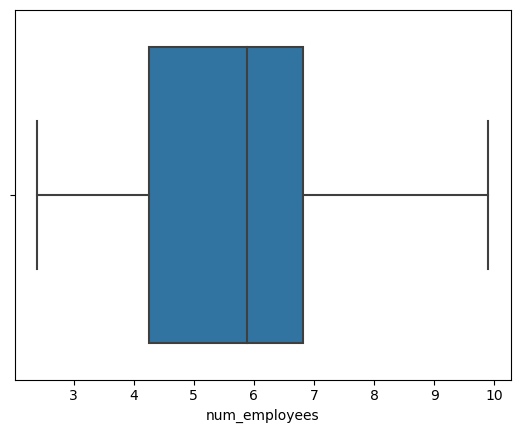

In [14]:
# Handle outlier
model_data = data.copy()

#log transform num_employees
model_data["num_employees"] = np.log1p(num_data["num_employees"])

# Show num_employees plot to check
sns.boxplot(x=model_data['num_employees'])
plt.show()

#columns to be capped
cap_cols = ['ai_budget_percentage','ai_training_hours','task_automation_rate','time_saved_per_week',
            'productivity_change_percent','employee_satisfaction_score','remote_work_percentage']
for col in cap_cols:
    lower = num_data[col].quantile(0.01)
    upper = num_data[col].quantile(0.99)
    model_data[col] = num_data[col].clip(lower, upper)

#do not need to be handled as they have upper bonds in nature
no_handle_col = ['num_ai_tools_used','ai_projects_active','years_using_ai'] 
for col in no_handle_col:
    model_data[col] = num_data[col]

In [15]:
#evaluate target feature
model_data['productivity_change_percent'].skew()

0.09864148758948031

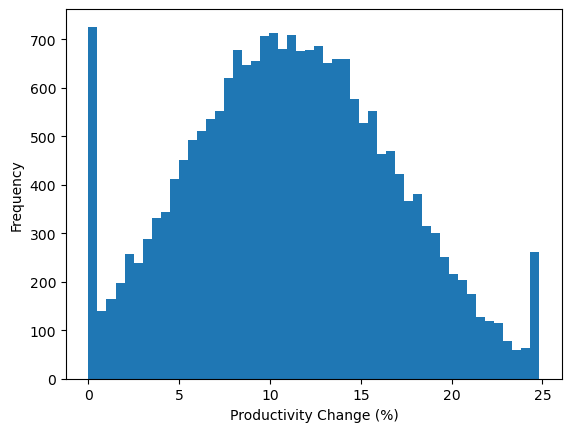

In [16]:
plt.hist(model_data['productivity_change_percent'], bins=50)
plt.xlabel("Productivity Change (%)")
plt.ylabel("Frequency")
plt.show()

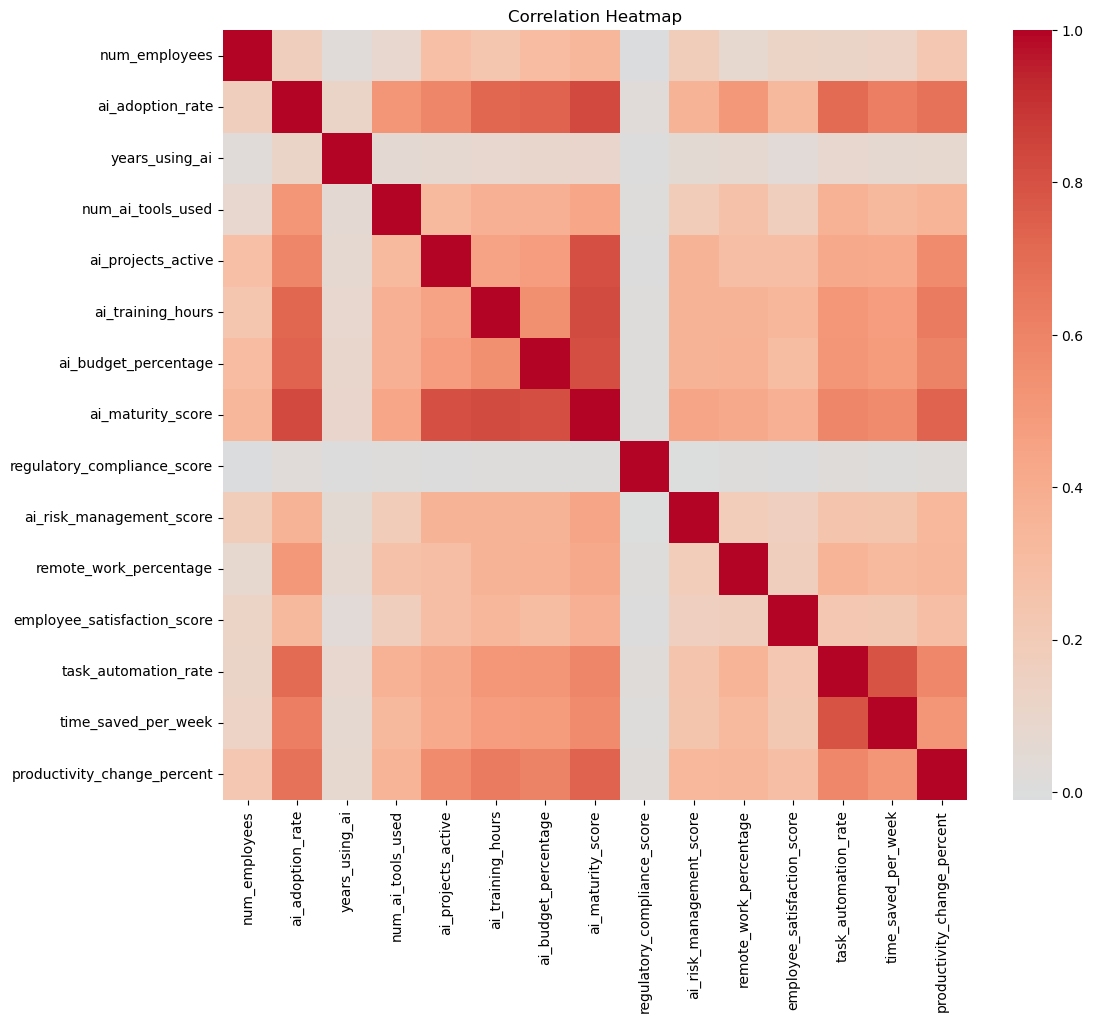

In [17]:
#check correlation between features
num_cols = model_data.select_dtypes(include=['int64','float64']).columns

corr = model_data[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
#check correlation with the target for a overview
num_cols = model_data.select_dtypes(include=['int64','float64']).columns
corr = model_data[num_cols].corr()
target_corr = corr['productivity_change_percent'].sort_values(ascending=False)
print(target_corr)

productivity_change_percent    1.000000
ai_maturity_score              0.736995
ai_adoption_rate               0.672648
ai_training_hours              0.633792
ai_budget_percentage           0.604373
task_automation_rate           0.582615
ai_projects_active             0.564782
time_saved_per_week            0.520118
num_ai_tools_used              0.357121
remote_work_percentage         0.337459
ai_risk_management_score       0.333566
employee_satisfaction_score    0.292749
num_employees                  0.232398
years_using_ai                 0.079844
regulatory_compliance_score    0.022993
Name: productivity_change_percent, dtype: float64


In [19]:
#Drop low relation features
data = data.drop(['regulatory_compliance_score','years_using_ai', 'num_employees', 'employee_satisfaction_score', 
                  'ai_risk_management_score', 'remote_work_percentage', 'num_ai_tools_used'], axis=1)

print("Columns: ", len(data.columns))
data.columns

Columns:  15


Index(['region', 'company_size', 'company_age_group', 'ai_adoption_rate',
       'ai_adoption_stage', 'ai_use_case', 'ai_projects_active',
       'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score',
       'data_privacy_level', 'ai_ethics_committee', 'task_automation_rate',
       'time_saved_per_week', 'productivity_change_percent'],
      dtype='object')

In [20]:
# Analyse categorical impact on target
for col in cat_data.columns:
    print()
    print(data.groupby(col)['productivity_change_percent'].mean().sort_values())


region
Africa           10.356726
Asia             11.016013
Europe           11.200174
South America    11.234148
Oceania          11.935274
North America    12.421949
Name: productivity_change_percent, dtype: float64

company_size
Startup       10.048520
SME           10.742487
Enterprise    13.946549
Name: productivity_change_percent, dtype: float64

company_age_group
0-5 years      10.745685
6-15 years     11.090769
16-30 years    11.206874
30+ years      11.506856
Name: productivity_change_percent, dtype: float64

ai_adoption_stage
none        2.379102
pilot       6.805328
partial    12.852828
full       19.963528
Name: productivity_change_percent, dtype: float64

ai_use_case
Customer Support        11.128468
Marketing Automation    11.135588
Software Development    11.198073
HR Automation           11.202289
Name: productivity_change_percent, dtype: float64

data_privacy_level
Low       11.074884
Medium    11.150087
High      11.226986
Name: productivity_change_percent, dtype: f

In [21]:
#Drop low relevance features
model_data = model_data.drop(['ai_use_case', 'data_privacy_level', 'region', 'company_size',
                              'ai_maturity_score', 'company_age_group', 'ai_ethics_committee'], axis=1)
print("Columns: ", len(data.columns))
model_data.columns

Columns:  15


Index(['num_employees', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'num_ai_tools_used', 'ai_projects_active',
       'ai_training_hours', 'ai_budget_percentage',
       'regulatory_compliance_score', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent'],
      dtype='object')

In [22]:
model_data["automation_effect"] = (
    model_data["task_automation_rate"] * model_data["time_saved_per_week"]
)

model_data["ai_investment_intensity"] = (
    model_data["ai_budget_percentage"] * model_data["ai_training_hours"]
)

In [23]:
#Encode categorical features for training
ecd_model_data = pd.get_dummies(model_data, drop_first=True)
ecd_model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21107 entries, 191 to 149833
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   num_employees                21107 non-null  float64
 1   ai_adoption_rate             21107 non-null  float64
 2   years_using_ai               21107 non-null  int64  
 3   num_ai_tools_used            21107 non-null  int64  
 4   ai_projects_active           21107 non-null  int64  
 5   ai_training_hours            21107 non-null  float64
 6   ai_budget_percentage         21107 non-null  float64
 7   regulatory_compliance_score  21107 non-null  int64  
 8   ai_risk_management_score     21107 non-null  int64  
 9   remote_work_percentage       21107 non-null  float64
 10  employee_satisfaction_score  21107 non-null  float64
 11  task_automation_rate         21107 non-null  float64
 12  time_saved_per_week          21107 non-null  float64
 13  productivity_chang

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor

In [25]:
# features and target
X = ecd_model_data.drop('productivity_change_percent', axis=1)
y = ecd_model_data['productivity_change_percent']

# Train-test split, first split (train, temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# second split (validation, test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

In [26]:
#Scale data for linear regrassion model
scaler = StandardScaler()

# fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform validation and test using same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [27]:
print(np.mean(X_train_scaled))
print(np.std(X_train_scaled))

-1.0773086016668637e-16
0.9999999999999998


In [28]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
pred = model.predict(X_val_scaled)

print("R2:", r2_score(y_val, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, pred)))

R2: 0.5721069969959018
RMSE: 3.6850900907984565


In [29]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_val_scaled)

print("Ridge R2:", r2_score(y_val, ridge_pred))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_val, ridge_pred)))

Ridge R2: 0.5721053852329232
Ridge RMSE: 3.685097031185593


In [30]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_val_scaled)

print("Lasso R2:", r2_score(y_val, lasso_pred))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_val, lasso_pred)))

Lasso R2: 0.572110941073684
Lasso RMSE: 3.685073107212206


In [31]:
lasso_cv = LassoCV(cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

val_pred = lasso_cv.predict(X_val_scaled)

print("Best alpha:", lasso_cv.alpha_)
print("Validation R2:", r2_score(y_val, val_pred))

Best alpha: 0.018096571907912414
Validation R2: 0.5722039466684228


In [32]:
elastic_cv = ElasticNetCV(
    l1_ratio=[0.1,0.3,0.5,0.7,0.9],
    cv=5,
    random_state=42
)

elastic_cv.fit(X_train_scaled, y_train)
elastic_pred = elastic_cv.predict(X_val_scaled)
print("ElasticNet R2:", r2_score(y_val, elastic_pred))
print("ElasticNet RMSE:", np.sqrt(mean_squared_error(y_val, elastic_pred)))

ElasticNet R2: 0.5721743436294495
ElasticNet RMSE: 3.6848000788372395


In [33]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

print("Random Forest R2:", r2_score(y_val, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_val, rf_pred)))

Random Forest R2: 0.5613141936277191
Random Forest RMSE: 3.7312754337584972


In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression
lin_model = LinearRegression()
lin_cv_r2 = cross_val_score(lin_model, X_train_scaled, y_train, cv=kf, scoring='r2')
lin_cv_mse = -cross_val_score(lin_model, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')

print("Linear Regression CV R2:", lin_cv_r2.mean())
print("Linear Regression CV RMSE:", np.sqrt(lin_cv_mse.mean()))

# Ridge Regression with built-in tuning
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5)
ridge_model.fit(X_train_scaled, y_train)

# Lasso Regression with built-in tuning
lasso_model = LassoCV(alphas=np.logspace(-3, 1, 20), cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Elastic Net with built-in tuning
elastic_model = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=np.logspace(-3, 1, 20),
    cv=5,
    random_state=42,
    max_iter=10000
)
elastic_model.fit(X_train_scaled, y_train)

Linear Regression CV R2: 0.5788167828124036
Linear Regression CV RMSE: 3.6741182250529003


ElasticNetCV(alphas=array([1.00000000e-03, 1.62377674e-03, 2.63665090e-03, 4.28133240e-03,
       6.95192796e-03, 1.12883789e-02, 1.83298071e-02, 2.97635144e-02,
       4.83293024e-02, 7.84759970e-02, 1.27427499e-01, 2.06913808e-01,
       3.35981829e-01, 5.45559478e-01, 8.85866790e-01, 1.43844989e+00,
       2.33572147e+00, 3.79269019e+00, 6.15848211e+00, 1.00000000e+01]),
             cv=5, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], max_iter=10000,
             random_state=42)

In [35]:
poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

poly2_cv_r2 = cross_val_score(poly2_model, X_train, y_train, cv=kf, scoring='r2')
poly2_cv_mse = -cross_val_score(poly2_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

print("Polynomial Degree 2 CV R2:", poly2_cv_r2.mean())
print("Polynomial Degree 2 CV RMSE:", np.sqrt(poly2_cv_mse.mean()))

Polynomial Degree 2 CV R2: 0.5729706888774508
Polynomial Degree 2 CV RMSE: 3.6996939663085526


In [36]:
# Linear Regression
lin_model.fit(X_train_scaled, y_train)
lin_val_pred = lin_model.predict(X_val_scaled)

# Ridge
ridge_val_pred = ridge_model.predict(X_val_scaled)

# Lasso
lasso_val_pred = lasso_model.predict(X_val_scaled)

# Elastic Net
elastic_val_pred = elastic_model.predict(X_val_scaled)

# Polynomial degree 2
poly2_model.fit(X_train, y_train)
poly2_val_pred = poly2_model.predict(X_val)

In [37]:
val_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Elastic Net",
        "Polynomial Regression (deg=2)"
    ],
    "R2": [
        r2_score(y_val, lin_val_pred),
        r2_score(y_val, ridge_val_pred),
        r2_score(y_val, lasso_val_pred),
        r2_score(y_val, elastic_val_pred),
        r2_score(y_val, poly2_val_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, lin_val_pred)),
        np.sqrt(mean_squared_error(y_val, ridge_val_pred)),
        np.sqrt(mean_squared_error(y_val, lasso_val_pred)),
        np.sqrt(mean_squared_error(y_val, elastic_val_pred)),
        np.sqrt(mean_squared_error(y_val, poly2_val_pred))
    ]
})

print(val_results.sort_values(by="R2", ascending=False))

                           Model        R2      RMSE
2                          Lasso  0.572206  3.684664
3                    Elastic Net  0.572156  3.684879
0              Linear Regression  0.572107  3.685090
1                          Ridge  0.571935  3.685831
4  Polynomial Regression (deg=2)  0.568117  3.702232


In [38]:
coef = pd.Series(lasso_model.coef_, index=X_train.columns)

coef.sort_values(ascending=False)

ai_training_hours              1.274275
ai_projects_active             1.241447
task_automation_rate           1.162762
ai_budget_percentage           0.884741
ai_investment_intensity        0.473870
ai_adoption_stage_partial      0.121914
automation_effect              0.091480
regulatory_compliance_score    0.067839
ai_risk_management_score       0.055171
num_ai_tools_used              0.042469
employee_satisfaction_score    0.042467
num_employees                  0.035685
ai_adoption_rate               0.007485
ai_adoption_stage_none         0.000000
remote_work_percentage         0.000000
time_saved_per_week            0.000000
years_using_ai                 0.000000
ai_adoption_stage_pilot       -0.121388
dtype: float64

In [39]:
# Perfrom Feedforward Neural Network
# Use Rectified Linear Unit Function with 2 hidden layers (64 and 32 neurons)
from sklearn.neural_network import MLPRegressor

mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), 
                         activation='relu', 
                         solver='adam', 
                         max_iter=1000, 
                         random_state=42)

# Fit the model on training data
mlp_model.fit(X_train_scaled, y_train)

# Predict on validation set
mlp_val_pred = mlp_model.predict(X_val_scaled)

In [40]:

r2 = r2_score(y_val, mlp_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, mlp_val_pred))

new_data = pd.DataFrame([{"Model": "Deep Learning (MLP)", "R2": r2, "RMSE": rmse}])
val_results = pd.concat([val_results, new_data], ignore_index=True)

print(val_results)

                           Model        R2      RMSE
0              Linear Regression  0.572107  3.685090
1                          Ridge  0.571935  3.685831
2                          Lasso  0.572206  3.684664
3                    Elastic Net  0.572156  3.684879
4  Polynomial Regression (deg=2)  0.568117  3.702232
5            Deep Learning (MLP)  0.502359  3.974098


#### We can see that lasso regression outperformed the Deep Learning result. This is due to the characteristic of deep learning, which is most useful for dealing with large amounts of unstructured data (images, audio, text). For structured data that is small to mid-sized (our case), traditional ML tools like regression is often preferred over DL.

In [51]:
# Define 4D State Space
budget_steps = np.linspace(0, 20, 11)      # 0% to 20%
training_steps = np.linspace(0, 100, 11)   # 0 to 100 hours
automation_steps = np.linspace(0, 100, 11) # 0% to 100%
project_steps = np.linspace(0, 20, 11)     # 0 to 20 projects

n_b, n_t, n_a, n_p = 11, 11, 11, 11
n_states = n_b * n_t * n_a * n_p
n_actions = 8 # +/- for each of the 4 variables

# Initialize Q-table
Q_table = np.zeros((n_states, n_actions))

In [52]:
learning_rate = 0.65
discount_factor = 0.7
exploration_prob = 1.0
decay_rate = 0.002 
epochs = 5000      

def get_state_idx(b, t, a, p):
    return (((b * n_t + t) * n_a + a) * n_p + p)

# Get Reward (Productivity) from pre-trained model
def get_reward(b_idx, t_idx, a_idx, p_idx):
    sample = X_val.iloc[0:1].copy()
    sample['ai_budget_percentage'] = budget_steps[b_idx]
    sample['ai_training_hours'] = training_steps[t_idx]
    sample['task_automation_rate'] = automation_steps[a_idx]
    sample['ai_projects_active'] = project_steps[p_idx]
    
    # Scale and predict using Lasso model which has the highest R2
    sample["ai_investment_intensity"] = sample['ai_budget_percentage'] * sample['ai_training_hours']
    sample["automation_effect"] = sample['task_automation_rate'] * sample['time_saved_per_week']
    
    scaled_sample = scaler.transform(sample)
    return lasso_model.predict(scaled_sample)[0]

In [53]:
for epoch in range(epochs):
   # Start at random 4D state
    b, t, a, p = np.random.randint(0, 11, 4)
    state = get_state_idx(b, t, a, p)
    
    # Explore or Exploit
    if np.random.uniform(0, 1) < exploration_prob:
        action = np.random.randint(0, n_actions)
    else:
        action = np.argmax(Q_table[state])

In [55]:
# Reset exploration probability for the 4D search 
exploration_prob = 1.0 

for epoch in range(epochs):
    # Start at a random 4D state (Initial position in the grid) 
    b, t, a, p = np.random.randint(0, 11, 4)
    state = get_state_idx(b, t, a, p)
    
    # Epsilon-greedy strategy: Explore or Exploit 
    if np.random.uniform(0, 1) < exploration_prob:
        action = np.random.randint(0, n_actions)
    else:
        action = np.argmax(Q_table[state])
    
    # Initialize next state indices at current levels
    nb, nt, na, np_idx = b, t, a, p 
    
    # Execute one of the 8 actions within realistic bounds 
    if action == 0 and b < n_b-1: nb += 1       # Budget +
    elif action == 1 and b > 0: nb -= 1         # Budget -
    elif action == 2 and t < n_t-1: nt += 1     # Training +
    elif action == 3 and t > 0: nt -= 1         # Training -
    elif action == 4 and a < n_a-1: na += 1     # Automation +
    elif action == 5 and a > 0: na -= 1         # Automation -
    elif action == 6 and p < n_p-1: np_idx += 1 # Projects +
    elif action == 7 and p > 0: np_idx -= 1     # Projects -
    
    # Calculate Reward and Update Q-table 
    new_state = get_state_idx(nb, nt, na, np_idx)
    reward = get_reward(nb, nt, na, np_idx)
    
    Q_table[state, action] = Q_table[state, action] + learning_rate * (
        reward + discount_factor * np.max(Q_table[new_state]) - Q_table[state, action]
    )
    
    # Decay exploration to favor learned knowledge over time 
    if exploration_prob > 0.01:
        exploration_prob -= decay_rate

In [56]:
# Find the absolute best state learned by the agent
best_state_idx = np.argmax(np.max(Q_table, axis=1))

# Deconstruct the 1D index back into 4D coordinates
p_final = best_state_idx % n_p
a_final = (best_state_idx // n_p) % n_a
t_final = (best_state_idx // (n_p * n_a)) % n_t
b_final = (best_state_idx // (n_p * n_a * n_t))

print("\n" + "="*45)
print("FINAL 4-VARIABLE OPTIMAL CONFIGURATION")
print("="*45)
print(f"Optimal AI Budget:        {budget_steps[b_final]:.1f}%")
print(f"Optimal Training:         {training_steps[t_final]:.1f} Hours")
print(f"Optimal Automation Rate:  {automation_steps[a_final]:.1f}%")
print(f"Optimal Active Projects:  {project_steps[p_final]:.0f}")
print("-" * 45)
print(f"MAX PREDICTED PRODUCTIVITY: {get_reward(b_final, t_final, a_final, p_final):.2f}%")
print("="*45)


FINAL 4-VARIABLE OPTIMAL CONFIGURATION
Optimal AI Budget:        20.0%
Optimal Training:         80.0 Hours
Optimal Automation Rate:  10.0%
Optimal Active Projects:  20
---------------------------------------------
MAX PREDICTED PRODUCTIVITY: 23.54%
